In [2]:
import numpy as np 
import pandas as  pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("heart.csv")

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


EDA


In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [6]:
df.shape

(880, 12)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 880 entries, 0 to 879
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             880 non-null    int64  
 1   Sex             880 non-null    str    
 2   ChestPainType   880 non-null    str    
 3   RestingBP       880 non-null    int64  
 4   Cholesterol     880 non-null    int64  
 5   FastingBS       880 non-null    int64  
 6   RestingECG      880 non-null    str    
 7   MaxHR           880 non-null    int64  
 8   ExerciseAngina  880 non-null    str    
 9   Oldpeak         880 non-null    float64
 10  ST_Slope        880 non-null    str    
 11  HeartDisease    880 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 82.6 KB


In [8]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000,880.000000
mean,53.464773,132.237500,197.640909,0.236364,136.282955,0.885682,0.554545
std,9.474888,18.600811,111.164027,0.425090,25.519328,1.059772,0.497299
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,170.750000,0.000000,119.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,137.000000,0.600000,1.000000
75%,60.000000,140.000000,268.000000,0.000000,155.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [9]:
df.duplicated().sum()

0

<Axes: xlabel='HeartDisease'>

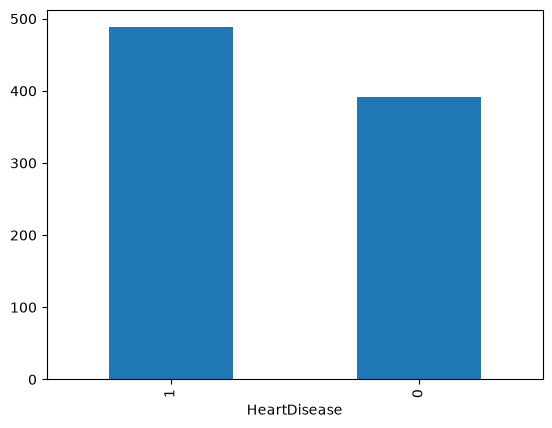

In [10]:
df["HeartDisease"].value_counts().plot(kind="bar")

In [11]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

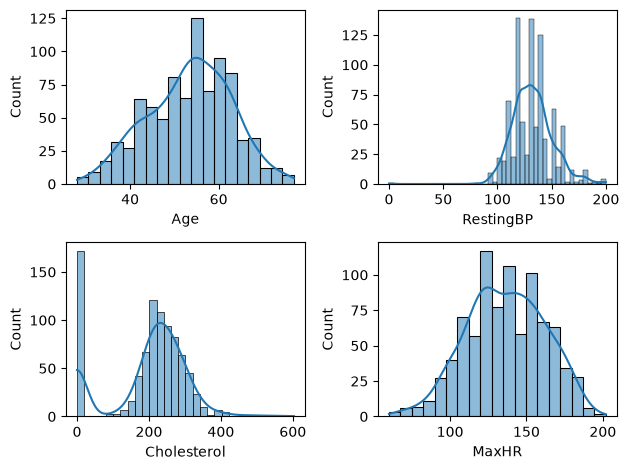

In [12]:
def ploting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

ploting('Age',1)
ploting('RestingBP',2)
ploting('Cholesterol',3)
ploting('MaxHR',4)

plt.tight_layout()

In [13]:
df['Cholesterol'].value_counts()

Cholesterol
0      172
254     11
211      9
223      9
230      9
      ... 
174      1
183      1
321      1
353      1
335      1
Name: count, Length: 218, dtype: int64

In [14]:
df['FastingBS'].value_counts()

FastingBS
0    672
1    208
Name: count, dtype: int64

In [15]:
ch_mean =df.loc[df['Cholesterol']!=0,'Cholesterol'].mean()

In [16]:
ch_mean

245.65536723163842

In [17]:
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean)

In [18]:
df['Cholesterol']=df['Cholesterol'].round(2)

In [19]:
restingBP=df.loc[df['RestingBP'] != 0,'RestingBP'].mean()
df['RestingBP'] = df['RestingBP'].replace(0,restingBP)
df['RestingBP']=df['RestingBP'].round(2)

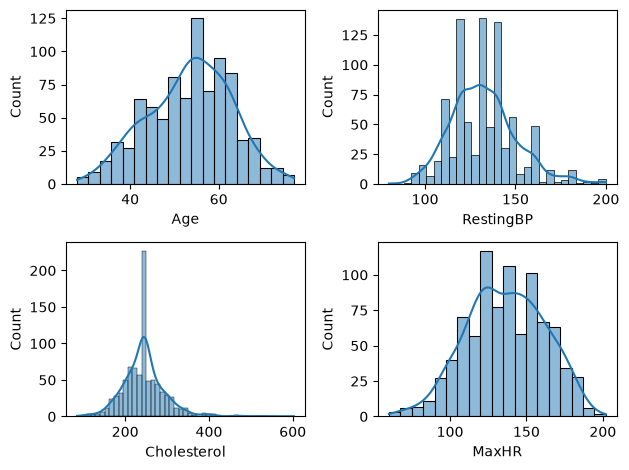

In [20]:
def ploting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)

ploting('Age',1)
ploting('RestingBP',2)
ploting('Cholesterol',3)
ploting('MaxHR',4)

plt.tight_layout()

In [21]:
pip install sheryanalysis==0.1.0

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [22]:
import sheryanalysis as sh 
sh.analyze(df)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (880, 12)
🧱 Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

✅ No null values found

🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


{'shape': (880, 12),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': <StringDtype(storage='python', na_value=nan)>,
  'ChestPainType': <StringDtype(storage='python', na_value=nan)>,
  'RestingBP': dtype('float64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': <StringDtype(storage='python', na_value=nan)>,
  'MaxHR': dtype('int64'),
  'ExerciseAngina': <StringDtype(storage='python', na_value=nan)>,
  'Oldpeak': dtype('float64'),
  'ST_Slope': <StringDtype(storage='python', na_value=nan)>,
  'HeartDisease': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0},
 'total_rows': 880,
 'c

<Axes: xlabel='Sex', ylabel='count'>

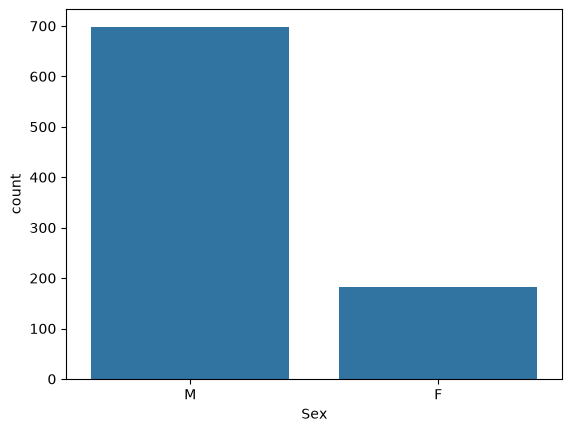

In [23]:
sns.countplot(x=df['Sex'])

<Axes: xlabel='ChestPainType', ylabel='count'>

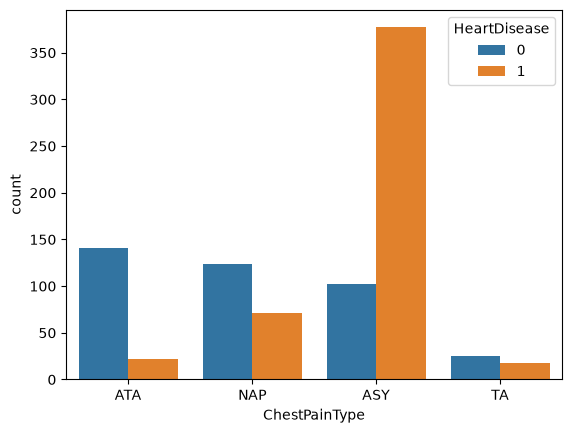

In [24]:
sns.countplot(x=df['ChestPainType'],hue=df['HeartDisease'])

<Axes: xlabel='Sex', ylabel='count'>

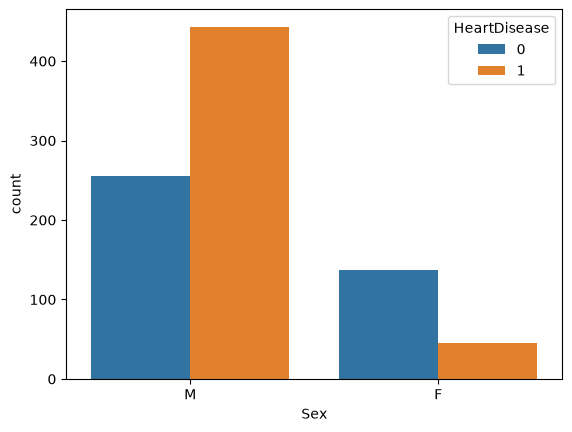

In [25]:
sns.countplot(x=df['Sex'],hue=df['HeartDisease'])

<Axes: xlabel='FastingBS', ylabel='count'>

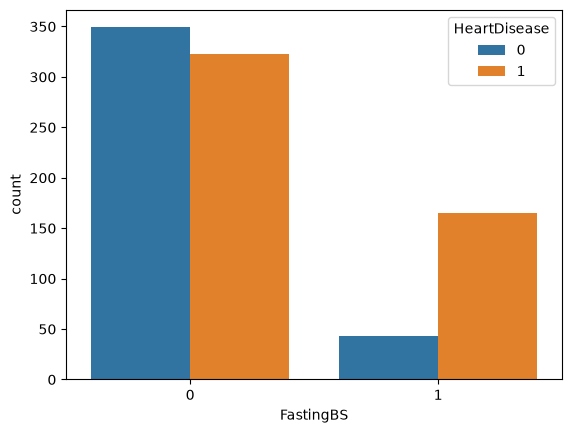

In [26]:
sns.countplot(x=df['FastingBS'],hue=df['HeartDisease'])

<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

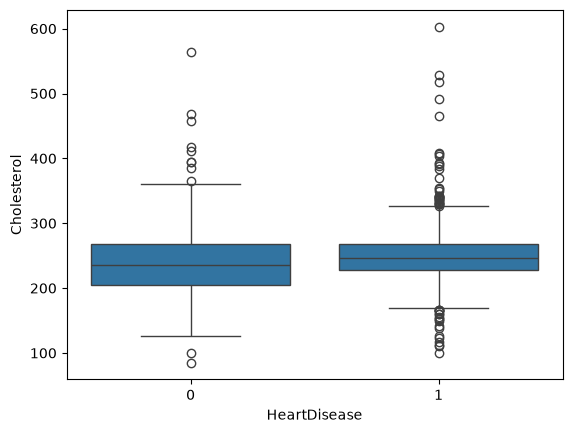

In [27]:
sns.boxplot(x='HeartDisease', y='Cholesterol',data=df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

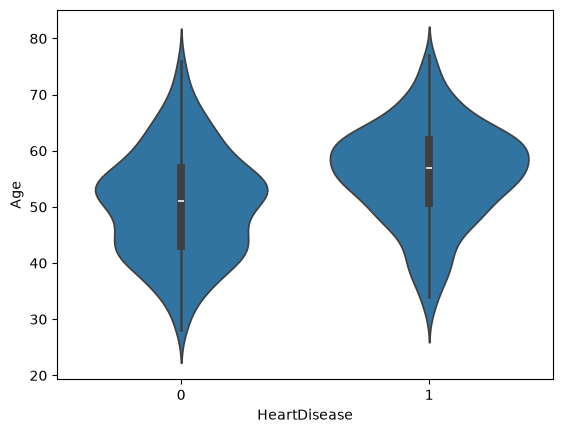

In [28]:
sns.violinplot(x='HeartDisease' , y = 'Age' ,data=df)

<Axes: >

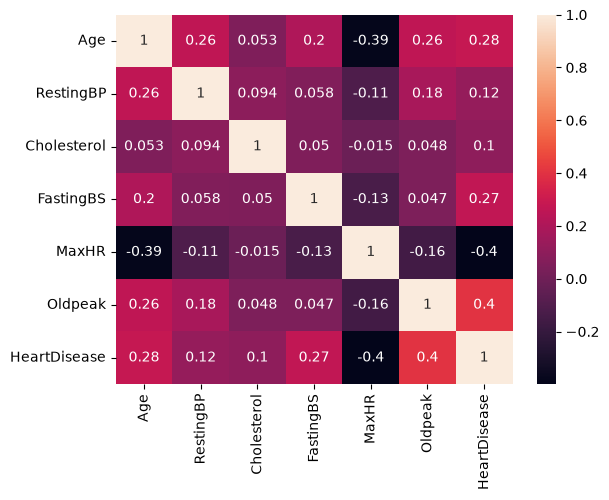

In [29]:
sns.heatmap(df.corr(numeric_only = True),annot=True)

data preprocessing and cleaning

In [31]:
df_encode=pd.get_dummies(df,drop_first=True)

In [32]:
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,58,120.0,340.0,0,172,0.0,0,False,False,True,False,True,False,False,False,True
876,60,130.0,206.0,0,132,2.4,1,True,False,False,False,False,False,True,True,False
877,58,120.0,284.0,0,160,1.8,1,True,True,False,False,False,False,False,True,False
878,49,130.0,266.0,0,171,0.6,0,True,True,False,False,True,False,False,False,True


In [33]:
df_encode=df_encode.astype(int)
df_encode

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
875,58,120,340,0,172,0,0,0,0,1,0,1,0,0,0,1
876,60,130,206,0,132,2,1,1,0,0,0,0,0,1,1,0
877,58,120,284,0,160,1,1,1,1,0,0,0,0,0,1,0
878,49,130,266,0,171,0,0,1,1,0,0,1,0,0,0,1


standard scaling

In [37]:
from sklearn.preprocessing import StandardScaler
numerical_cols=['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']
scaler =StandardScaler()
df_encode[numerical_cols]=scaler.fit_transform(df_encode[numerical_cols])
df_encode.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.421909,0.421809,0.813770,0,1.400403,-0.733390,0,1,1,0,0,1,0,0,0,1
1,-0.471490,1.530011,-1.226611,0,0.773071,0.284564,1,0,0,1,0,1,0,0,1,0
2,-1.738716,-0.132292,0.701456,0,-1.501008,-0.733390,0,1,1,0,0,0,1,0,0,1
3,-0.577092,0.310989,-0.590162,0,-1.108926,0.284564,1,0,0,0,0,1,0,1,1,0
4,0.056521,0.975910,-0.945825,0,-0.560010,-0.733390,0,1,0,1,0,1,0,0,0,1
